<a href="https://colab.research.google.com/github/kazi-amir/ml-learning/blob/main/pytorch-5-projects/2-image-classification-animal-face.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project - 2: Animal Face Image Classification

## Downloading Dataset

In [1]:
import re

# Paste your Kaggle dataset URL here
dataset_url = "https://www.kaggle.com/datasets/andrewmvd/animal-faces"
# Extract the owner/name from the URL
match = re.search(r'datasets/([^/]+/[^/?#]+)', dataset_url)
if match:
    dataset_slug = match.group(1)
    print(f"Downloading dataset: {dataset_slug}")

    # Use get_ipython().system for indented shell commands in Colab
    get_ipython().system(f"kaggle datasets download -d {dataset_slug}")

    print("Download complete!")

    # Extract the zip file
    print("Extracting files...")
    get_ipython().system("unzip -oq *.zip")
    print("Unzipping complete!")
else:
    print("Could not parse Kaggle URL. Please check the format.")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 696M/696M [00:34<00:00, 20.9MB/s]

Download complete!
Extracting files...
Unzipping complete!


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
image_path = []
labels = []

for i in os.listdir("/content/afhq"):
  print(i)
  for label in os.listdir(f"/content/afhq/{i}"):
    for image in os.listdir(f"/content/afhq/{i}/{label}"):
      image_path.append(f"/content/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels),
                       columns = ["image_path", "labels"]
                    )
data_df.head()

train
val


,image_path,labels
0,/content/afhq/train/cat/pixabay_cat_004560.jpg,cat
1,/content/afhq/train/cat/pixabay_cat_000258.jpg,cat
2,/content/afhq/train/cat/pixabay_cat_002352.jpg,cat
3,/content/afhq/train/cat/pixabay_cat_000155.jpg,cat
4,/content/afhq/train/cat/pixabay_cat_004375.jpg,cat


In [5]:
data_df["labels"].nunique(), data_df["labels"].value_counts()

(3,
 labels
 cat     5653
 dog     5239
 wild    5238
 Name: count, dtype: int64)

In [6]:
train = data_df.sample(frac = 0.7, random_state = 42)
val_test = data_df.drop(train.index)

val = val_test.sample(frac = 0.5, random_state = 42)
test = val_test.drop(val.index)

In [7]:
train.shape, val.shape, test.shape

((11291, 2), (2420, 2), (2419, 2))

In [8]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float32)
  ])

In [9]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

LabelEncoder()

In [10]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    image_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(image_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [11]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)

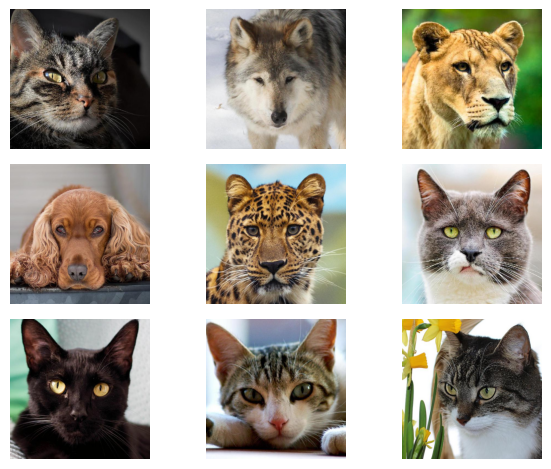

In [12]:
n_rows = 3
n_cols = 3
fig, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis("off")

plt.tight_layout()
plt.show()

In [13]:
LR = 0.0001
BATCH_SIZE = 16

In [14]:
train_dataloader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_dataloader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

## Neural Network Model building

In [15]:
class ClassificationNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

    self.pooling = nn.MaxPool2d(2, 2)

    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()

    self.linear = nn.Linear(in_features=128 * 16 * 16, out_features=128)
    self.output = nn.Linear(in_features=128, out_features=len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x) # (32, 128, 128)
    x = self.pooling(x) #(32, 64, 64)
    x = self.relu(x) # (32, 64, 64)

    x = self.conv2(x) # (64, 64, 64)
    x = self.pooling(x) # (64, 32, 32)
    x = self.relu(x) # (64, 32, 32)

    x = self.conv3(x) # (128, 32, 32)
    x = self.pooling(x) #(128, 16, 16)
    x = self.relu(x) # (128, 16, 16)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x

In [16]:
model_0 = ClassificationNN().to(device)
model_0

ClassificationNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=32768, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=3, bias=True)
)

In [17]:
summary(model_0, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [18]:
# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model_0.parameters(), lr = LR)

In [19]:
# Training Loop
EPOCHS = 10

train_loss_per_epoch = []
train_acc_per_epoch = []
val_loss_per_epoch = []
val_acc_per_epoch = []

for epoch in range(EPOCHS):
  total_train_acc = 0
  total_train_loss = 0
  total_val_acc = 0
  total_val_loss = 0

  # Model in Training Mode
  model_0.train()
  for x, y in train_dataloader:

    # Forward Pass
    predictions = model_0(x).squeeze(1)

    # Calculate the loss
    batch_loss = criterion(predictions, y)
    total_train_loss += batch_loss.item()

    batch_acc = (torch.argmax(predictions, dim = 1) == y).type(torch.float).mean().item()
    total_train_acc += batch_acc

    # Optimizer Zero Grad
    optimizer.zero_grad()

    # Backward Pass
    batch_loss.backward()

    # Optimizer Step
    optimizer.step()

  with torch.inference_mode():
    model_0.eval()
    for x, y in val_dataloader:
      predictions = model_0(x).squeeze(1)
      batch_loss = criterion(predictions, y)
      total_val_loss += batch_loss.item()
      batch_acc = (torch.argmax(predictions, dim = 1) == y).type(torch.float).mean().item()
      total_val_acc += batch_acc

  total_train_acc = total_train_acc / len(train_dataloader)
  total_train_loss = total_train_loss / len(train_dataloader)
  total_val_acc = total_val_acc / len(val_dataloader)
  total_val_loss = total_val_loss / len(val_dataloader)

  train_loss_per_epoch.append(total_train_loss)
  train_acc_per_epoch.append(total_train_acc * 100)
  val_loss_per_epoch.append(total_val_loss)
  val_acc_per_epoch.append(total_val_acc * 100)

  if epoch % 1 == 0:
    print(f"Epoch: {epoch} | Train Loss: {total_train_loss:.4f} | Train Acc: {total_train_acc * 100:.2f}% | Val Loss: {total_val_loss:.4f} | Val Acc: {total_val_acc * 100:.2f}%")

Epoch: 0 | Train Loss: 0.4901 | Train Acc: 79.38% | Val Loss: 0.3253 | Val Acc: 87.17%
Epoch: 1 | Train Loss: 0.2003 | Train Acc: 92.82% | Val Loss: 0.1699 | Val Acc: 93.87%
Epoch: 2 | Train Loss: 0.1286 | Train Acc: 95.39% | Val Loss: 0.1395 | Val Acc: 95.07%
Epoch: 3 | Train Loss: 0.0899 | Train Acc: 96.80% | Val Loss: 0.1210 | Val Acc: 95.76%
Epoch: 4 | Train Loss: 0.0671 | Train Acc: 97.60% | Val Loss: 0.1329 | Val Acc: 95.11%
Epoch: 5 | Train Loss: 0.0455 | Train Acc: 98.54% | Val Loss: 0.1143 | Val Acc: 96.18%
Epoch: 6 | Train Loss: 0.0324 | Train Acc: 98.88% | Val Loss: 0.1261 | Val Acc: 96.05%
Epoch: 7 | Train Loss: 0.0294 | Train Acc: 99.05% | Val Loss: 0.1414 | Val Acc: 95.76%
Epoch: 8 | Train Loss: 0.0147 | Train Acc: 99.55% | Val Loss: 0.1349 | Val Acc: 96.18%
Epoch: 9 | Train Loss: 0.0175 | Train Acc: 99.45% | Val Loss: 0.1464 | Val Acc: 96.01%


In [20]:
# Test set
with torch.inference_mode():
  model_0.eval()

  total_test_acc = 0
  total_test_loss = 0

  for x, y in test_dataloader:
    predictions = model_0(x).squeeze(1)

    batch_loss = criterion(predictions, y)
    total_test_loss += batch_loss.item()
    batch_acc = (torch.argmax(predictions, dim = 1) == y).type(torch.float).mean().item()
    total_test_acc += batch_acc

  total_test_acc = total_test_acc / len(test_dataloader)
  total_test_loss = total_test_loss / len(test_dataloader)

  print(f"Test Loss: {total_test_loss:.4f} | Test Acc: {total_test_acc:.4f}")

Test Loss: 0.1242 | Test Acc: 0.9679


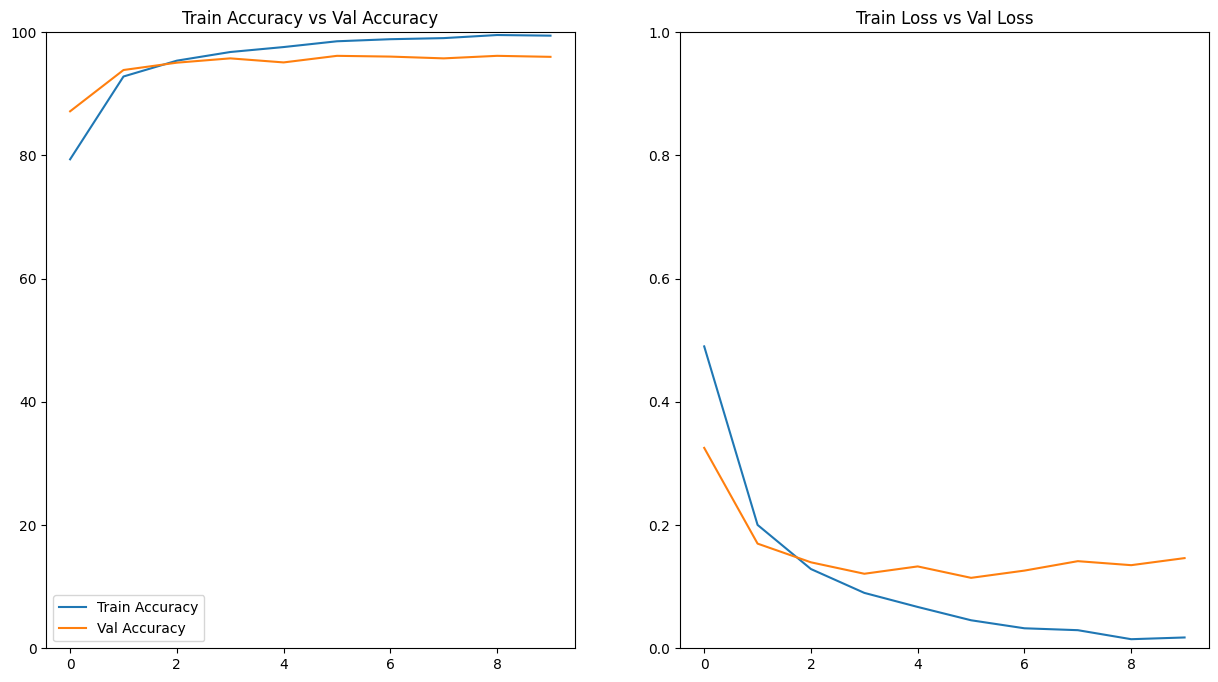

In [21]:
# Plot Train Accuracy vs Val Accuracy and Train Loss vs Val Loss

fig, axs = plt.subplots(1, 2, figsize=(15,8))
axs[0].plot(train_acc_per_epoch, label="Train Accuracy")
axs[0].plot(val_acc_per_epoch, label="Val Accuracy")
axs[0].set_title("Train Accuracy vs Val Accuracy")
axs[0].set_ylim(0, 100)
axs[0].legend()

axs[1].plot(train_loss_per_epoch, label="Train Loss")
axs[1].plot(val_loss_per_epoch, label="Val Loss")
axs[1].set_title("Train Loss vs Val Loss")
axs[1].set_ylim(0, 1)
axs[1].legend

plt.show()